# Import

In [1]:
%cd /Users/apple/big_vision/mmdetection

/Users/apple/big_vision/mmdetection


In [2]:
dataset_dir = '/Users/apple/big_vision/mmdetection/coco128'



In [3]:
import os
import random

img_dir = '/Users/apple/big_vision/mmdetection/coco128/images/train2017'
label_dir = '/Users/apple/big_vision/mmdetection/coco128/labels/train2017'

list_all_frame_raw = [x.split('.')[0] for x in os.listdir(img_dir)]

list_all_frame = []
for frame in list_all_frame_raw:
    img_path = os.path.join(img_dir, frame + '.jpg')
    label_path = os.path.join(label_dir, frame + '.txt')
    if not os.path.exists(img_path):
        print(f"img {img_path} not exist")
        continue
    if not os.path.exists(label_path):
        print(f"label {label_path} not exist")
        continue
    list_all_frame.append(frame)
    
num_train = int(len(list_all_frame) * 0.8)
num_val = len(list_all_frame) - num_train

random.shuffle(list_all_frame)

train_frames = list_all_frame[:num_train]
val_frames = list_all_frame[num_train:]

label /Users/apple/big_vision/mmdetection/coco128/labels/train2017/000000000508.txt not exist
label /Users/apple/big_vision/mmdetection/coco128/labels/train2017/000000000250.txt not exist


# Dataset

In [113]:
from PIL import Image
import torch
from torchvision import transforms as T
from mmdet.structures import DetDataSample
from mmengine.structures import InstanceData
import copy
import numpy as np


class Mydataset(torch.utils.data.Dataset):
    def __init__(
            self, 
            img_dir,
            label_dir, 
            frames, 
            transforms=None):
        super(Mydataset).__init__()

        self.img_dir = img_dir
        self.label_dir = label_dir
        self.frames = frames
        self.transforms = transforms
        
        self.img_size = 256
        
        self.img_metas = {
            'img_shape': (self.img_size, self.img_size),
            'pad_shape': (self.img_size, self.img_size),
            'scale_factor': [1,1],
        }
        
        self.resize = T.Resize((224, 224))




    def __getitem__(self, idx):
        frame = self.frames[idx]
        img_path = os.path.join(self.img_dir, frame + '.jpg')
        label_path = os.path.join(self.label_dir, frame + '.txt')
        
        img = Image.open(img_path).convert("RGB")
        labels = []
        with open(label_path, 'r') as f:
            for label in f:
                cat, x_center, y_center, width, height = label.strip().split()    
                x_center, y_center = float(x_center), float(y_center)            
                labels.append([x_center, y_center])
        labels = torch.as_tensor(labels, dtype=torch.float32)
        # print(labels)
        # img = img*255
        
        center1 = labels[0].tolist()
        center2 = [random.uniform(0.1, 0.9), random.uniform(0.1, 0.9)]
        center3 = [random.uniform(0.1, 0.9), random.uniform(0.1, 0.9)]
        
        xmin2 =  center1[0] - center2[0]*0.5
        # xmin2 = xmin2 if xmin2 >= 0 else 0
        xmax2 =  xmin2 + 0.5
        ymin2 =  center1[1] - center2[1]*0.5
        # ymin2 = ymin2 if ymin2 >= 0 else 0
        ymax2 =  ymin2 + 0.5
        
        xmin3 =  center1[0] - center3[0]*0.25
        # xmin3 = xmin3 if xmin3 >= 0 else 0
        xmax3 =  xmin3 + 0.25
        ymin3 =  center1[1] - center3[1]*0.25
        # ymin3 = ymin3 if ymin3 >= 0 else 0
        ymax3 =  ymin3 + 0.25
        
        xmin2, xmax2, ymin2, ymax2 = int(xmin2*224), int(xmax2*224), int(ymin2*224), int(ymax2*224)
        xmin3, xmax3, ymin3, ymax3 = int(xmin3*224), int(xmax3*224), int(ymin3*224), int(ymax3*224)
        # if self.transforms is not None:
        #     img = self.transforms(img)
        print(xmin2, xmax2, ymin2, ymax2)
        print(xmin3, xmax3, ymin3, ymax3)
        
        img = self.resize(img)
        img = np.array(img)
        
        img1 = copy.copy(img)
        img1 = Image.fromarray(img1)
        img2 = copy.copy(img)[ymin2:ymax2,xmin2:xmax2]
        img2 = Image.fromarray(img2)
        img2 = self.resize(img2)
        img3 = copy.copy(img)[ymin3:ymax3,xmin3:xmax3]
        img3 = Image.fromarray(img3)
        img3 = self.resize(img3)            
        return {
            'imagex1': img1,
            'imagex2': img2,
            'imagex3': img3,
            'center1': center1,
            'center2': center2,
            'center3': center3,
        }

    def __len__(self):
        return len(self.frames)

transforms = T.Compose([
    T.Resize((224, 256)),
    T.ToTensor(),
])
train_dataset = Mydataset(
    img_dir, 
    label_dir,
    train_frames, 
    transforms,
)
val_dataset = Mydataset(
    img_dir, 
    label_dir,
    val_frames, 
    transforms,
)

In [114]:
import random
random.random()

0.8441653193006082

In [115]:
val_dataset[0]

56 168 97 209
52 108 119 175


{'imagex1': <PIL.Image.Image image mode=RGB size=224x224>,
 'imagex2': <PIL.Image.Image image mode=RGB size=224x224>,
 'imagex3': <PIL.Image.Image image mode=RGB size=224x224>,
 'center1': [0.3862369954586029, 0.5617499947547913],
 'center2': [0.2645571307565323, 0.25425069744990003],
 'center3': [0.6133759311042548, 0.11546203141997138]}

15 127 32 144
80 136 113 169


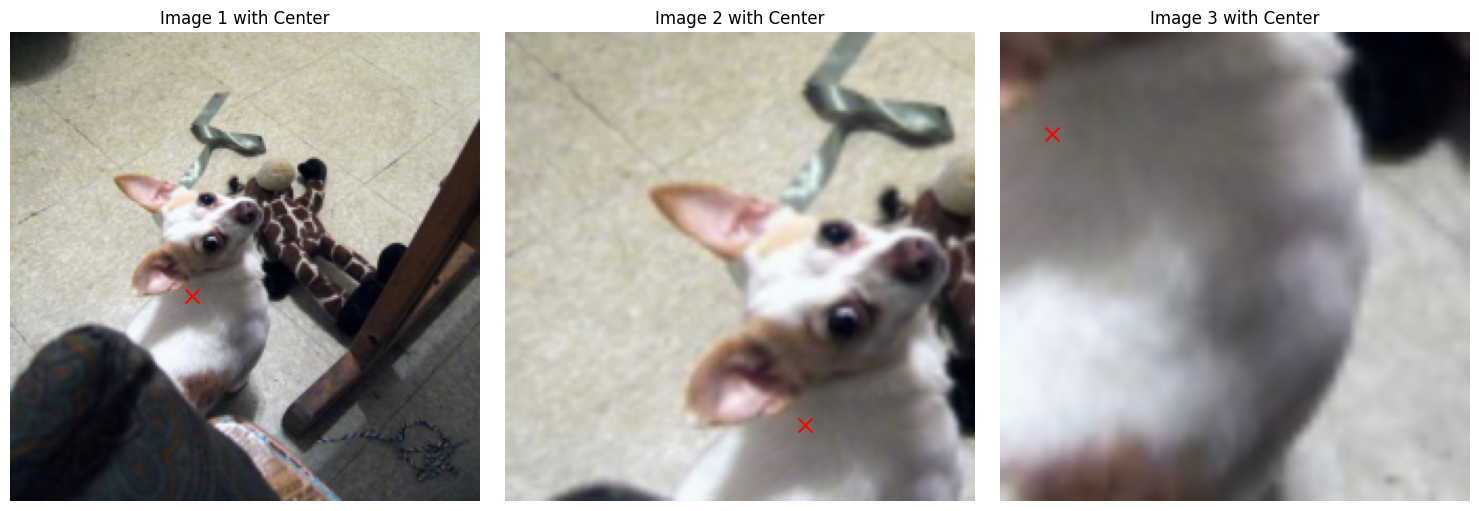

In [119]:
import matplotlib.pyplot as plt
import numpy as np
x = val_dataset[0]
imagex1 = x['imagex1']
imagex2 = x['imagex2']
imagex3 = x['imagex3']
center1 = x['center1']
center2 = x['center2']
center3 = x['center3']


# Example PIL Images and center coordinates
images = [imagex1, imagex2, imagex3]
centers = [center1, center2, center3]

# Plot images with centers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    width, height = images[i].size
    center_x = centers[i][0] * width
    center_y = centers[i][1] * height
    ax.scatter(center_x, center_y, color='red', marker='x', s=100)
    ax.set_title(f'Image {i+1} with Center')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [117]:
# import matplotlib.pyplot as plt
# import torch

# x = val_dataset[10]
# # Your provided tensor
# image_tensor = x['inputs']

# # Normalize tensor for visualization
# image_tensor = image_tensor / 255.0
# image_np = image_tensor.permute(1, 2, 0).numpy()

# # Visualize image
# plt.imshow(image_np)

# # Calculate center
# height, width = image_np.shape[:2]
# center_x, center_y = x['labels']

# center_x, center_y = center_x*width, height*center_y

# # Mark the center
# plt.scatter(center_x, center_y, color='red', s=100, marker='x')

# plt.title("Image with Center Marked")
# plt.axis('off')
# plt.show()


In [110]:
# val_dataset[0]['data_samples']

In [343]:
def collate_fn(batch):
    inputs = torch.stack([x['inputs'] for x in batch])
    data_samples = [x['data_samples'] for x in batch]
    return {
        'inputs': inputs,
        'data_samples': data_samples   
    }

In [429]:
# cfg

# Init model

In [346]:
from mmengine.config import Config, DictAction

cfg = Config.fromfile('/Users/apple/big_vision/mmdetection/configs/faster_rcnn/faster-rcnn_r50_fpn_1x_coco.py')
cfg['work_dir'] = ''
cfg.load_from = 'https://cdn-model.openxlab.org.cn/models%2Fweight%2Fmmdetection%2FFaster+R-CNN%2Ffaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth?Expires=1742556603&OSSAccessKeyId=LTAI5tCdKkrGqdpR7PDyejq7&Signature=19OCGIvcxzpl3BFpWUX4ka0ka3U%3D&response-content-disposition=attachment%3B%20filename%3Dfaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth'
from mmengine.runner import Runner

runner = Runner.from_cfg(cfg)

# losses = runner.model._run_forward(data, mode='loss')  # type: ignore
print('')

03/21 17:56:36 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: darwin
    Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
    CUDA available: False
    MUSA available: False
    numpy_random_seed: 410932581
    GCC: Apple clang version 14.0.3 (clang-1403.0.22.14.1)
    PyTorch: 2.5.1
    PyTorch compiling details: PyTorch built with:
  - GCC 4.2
  - C++ Version: 201703
  - clang 14.0.3
  - OpenMP 201811
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: NO AVX
  - Build settings: BLAS_INFO=accelerate, BUILD_TYPE=Release, CXX_COMPILER=/Applications/Xcode_14.3.1.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/clang++, CXX_FLAGS= -fvisibility-inlines-hidden -DUSE_PTHREADPOOL -DNDEBUG -DUSE_KINETO -DLIBKINETO_NOCUPTI -DLIBKINETO_NOROCTRACER -DLIBKINETO_NOXPUPTI=ON -DUSE_PYTORCH_QNNPACK -DAT_BUILD_ARM_VEC256_WITH_

/Users/apple/miniconda3/lib/python3.12/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


03/21 17:56:37 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/21 17:56:37 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

In [347]:
runner.load_or_resume()

Loads checkpoint by http backend from path: https://cdn-model.openxlab.org.cn/models%2Fweight%2Fmmdetection%2FFaster+R-CNN%2Ffaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth?Expires=1742556603&OSSAccessKeyId=LTAI5tCdKkrGqdpR7PDyejq7&Signature=19OCGIvcxzpl3BFpWUX4ka0ka3U%3D&response-content-disposition=attachment%3B%20filename%3Dfaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth
03/21 17:56:37 - mmengine - INFO - Load checkpoint from https://cdn-model.openxlab.org.cn/models%2Fweight%2Fmmdetection%2FFaster+R-CNN%2Ffaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth?Expires=1742556603&OSSAccessKeyId=LTAI5tCdKkrGqdpR7PDyejq7&Signature=19OCGIvcxzpl3BFpWUX4ka0ka3U%3D&response-content-disposition=attachment%3B%20filename%3Dfaster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth


In [348]:
from torch import nn
from transformers.modeling_outputs import ImageClassifierOutput

class WrapModel(nn.Module):
    def __init__(self, model):
        super(WrapModel, self).__init__()
        self.model = model
    def forward(self, inputs, data_samples=None):
        
        loss = None
        if self.training:
            loss_dict = self.model(inputs, data_samples, mode='loss')
            losses = []
            for k,v in loss_dict.items():
                if 'loss' in k:
                    if isinstance(v, torch.Tensor):
                        losses.append(v)
                    else:
                        losses.extend(v)
            # print(losses)
            loss = torch.stack(losses)
            # print(loss)
            loss = loss.sum()
            logits = None
        else:
            logits = self.model(inputs, data_samples, mode='predict')
            loss = None

        return ImageClassifierOutput(
            loss=loss,
            logits=logits,
        )
model = WrapModel(runner.model)    

In [392]:
model.to('cpu')
print('')

x = train_dataset[1]
data = collate_fn([x])

In [393]:
ori_img = np.array(data['inputs'][0].clone().permute(1,2,0), dtype=np.uint8)


In [394]:
runner.model.to('cpu')
print('')

In [395]:
data = runner.model.data_preprocessor(data, True)


In [428]:
runner.model.nms

AttributeError: 'FasterRCNN' object has no attribute 'nms'

In [434]:
# losses = runner.model(**data, mode='loss')  # type: ignore
model.eval()
model.model.rpn_head.test_cfg.nms.iou_threshold = 0.5
model.model.rpn_head.test_cfg.nms_pre = 1000
losses = model(**data)  # type: ignore



In [435]:
model.model.rpn_head

RPNHead(
  (loss_cls): CrossEntropyLoss(avg_non_ignore=False)
  (loss_bbox): L1Loss()
  (rpn_conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rpn_cls): Conv2d(256, 3, kernel_size=(1, 1), stride=(1, 1))
  (rpn_reg): Conv2d(256, 12, kernel_size=(1, 1), stride=(1, 1))
)
init_cfg={'type': 'Normal', 'layer': 'Conv2d', 'std': 0.01}

In [436]:
# losses

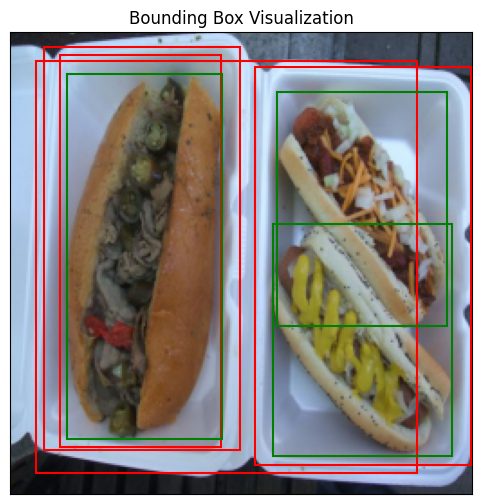

In [437]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib.patches as patches

# Image dimensions
img_shape = (256, 256)

# Predicted bounding boxes, labels, and scores
pred_bboxes = losses.logits[0].pred_instances.bboxes

# Ground truth bounding boxes and labels
gt_bboxes = losses.logits[0].gt_instances.bboxes

# Visualization
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, img_shape[1])
ax.set_ylim(img_shape[0], 0)  # Invert y-axis for correct visualization
ax.set_title("Bounding Box Visualization")
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(ori_img, extent=[0, img_shape[1], img_shape[0], 0])

# Draw predicted boxes
for bbox in pred_bboxes:
    x1, y1, x2, y2 = bbox.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor='r', facecolor='none', label='Predicted')
    ax.add_patch(rect)

# Draw ground truth boxes
for bbox in gt_bboxes:
    x1, y1, x2, y2 = bbox.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor='g', facecolor='none', label='Ground Truth')
    ax.add_patch(rect)

# plt.legend([patches.Patch(color='r', label='Predicted'), patches.Patch(color='g', label='Ground Truth')])
plt.show()


In [438]:
model

WrapModel(
  (model): FasterRCNN(
    (data_preprocessor): DetDataPreprocessor()
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): ResLayer(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [213]:
# data['data_samples'][0].metainfo['scale_factor']=[2,3]


In [214]:
data['data_samples'][0]


<DetDataSample(

    META INFORMATION
    img_shape: (256, 256)
    batch_input_shape: (256, 256)
    pad_shape: (256, 256)
    scale_factor: [1, 1]

    DATA FIELDS
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([], size=(0, 4), grad_fn=<SliceBackward0>)
            labels: tensor([], dtype=torch.int64)
            scores: tensor([], grad_fn=<SelectBackward0>)
        ) at 0x31a2f9b50>
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([[ 82.4200, 134.7057, 118.6921, 238.4335],
                        [176.0860, 153.8245, 329.3540, 358.1755],
                        [ 73.2319, 132.0264, 214.8797, 373.0675],
                        [ 87.4020, 128.5755, 207.1580, 265.2249]])
            labels: tensor([27,  0,  0, 76])
        ) at 0x31a38e600>
) at 0x31a38c1d0>

In [127]:
model.eval()
# data['data_samples'][0].metainfo['scale_factor']=[1]
losses = model(**data)  # type: ignore


TypeError: 'int' object is not iterable

In [53]:
data['data_samples'][0].metainfo['scale_factor']=[1]

In [76]:
losses

{'loss_rpn_cls': [tensor(0.5258, grad_fn=<MulBackward0>),
  tensor(0.1384, grad_fn=<MulBackward0>),
  tensor(0.0270, grad_fn=<MulBackward0>),
  tensor(0.0109, grad_fn=<MulBackward0>),
  tensor(0., grad_fn=<MulBackward0>)],
 'loss_rpn_bbox': [tensor(0., grad_fn=<SumBackward0>),
  tensor(0.0060, grad_fn=<MulBackward0>),
  tensor(0.0097, grad_fn=<MulBackward0>),
  tensor(0.0061, grad_fn=<MulBackward0>),
  tensor(0., grad_fn=<SumBackward0>)],
 'loss_cls': tensor(4.3645, grad_fn=<MulBackward0>),
 'acc': tensor([0.1953]),
 'loss_bbox': tensor(0.0087, grad_fn=<MulBackward0>)}

In [34]:
# !pip install transformers

In [35]:
# !pip install 'accelerate>=0.26.0'

In [103]:
from transformers import TrainingArguments
batch_size = 4

trainer_args = TrainingArguments(
    output_dir='./checkpoints',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=batch_size,  # batch size per device during training
    per_device_eval_batch_size=batch_size,   # batch size for evaluation
    # logging_dir='./logs',            # directory for storing logs
    # logging_steps=10,
    save_strategy = 'epoch',
    save_total_limit = 5,
    # load_best_model_at_end = True,
    logging_strategy = 'epoch',
    eval_strategy = 'epoch',
    # no_cuda=True,


)

                                                                          

In [104]:
# runner.model.device

In [105]:
# x = train_dataset[0]
# data = collate_fn([x])

In [106]:
# losses = runner.model(**data, mode='loss')  # type: ignore


In [107]:
# losses = runner.model._run_forward(data, mode='loss')  # type: ignore


In [108]:
# data = runner.model.data_preprocessor(data, True)
# losses = runner.model._run_forward(data, mode='loss')  # type: ignore


In [109]:
# runner.model(data)

In [110]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=trainer_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    # tokenizer=None,
)

In [111]:
trainer.train()

RuntimeError: nms_impl: implementation for device mps:0 not found.


In [42]:
# !ls /Users/apple/big_vision/mmdetection/coco128/labels/train2017/

In [112]:
# import torch
# import numpy as np
# from mmengine.structures import InstanceData
# from mmdet.structures import DetDataSample
# from mmdet.models.data_preprocessors import DetDataPreprocessor

# # from mmdet.structures import DetDataSample


# s = 256
# img_metas = {
#     'img_shape': (s, s),
#     'pad_shape': (s, s),
#     'scale_factor': 1,
# }

# input_tensor = torch.rand((1, 3, s, s))  # Example input image


# sample = DetDataSample()
# sample.set_metainfo(img_metas)

# # Test that empty ground truth encourages the network to
# # predict background
# gt_instances = InstanceData()
# # gt_instances.bboxes = torch.empty((0, 4))
# # gt_instances.labels = torch.LongTensor([])
# # gt_instances.bboxes = torch.tensor([[0.4997, 0.7707, 0.0595, 0.4188],
# #                         [0.8101, 0.3105, 0.5123, 0.6263],
# #                         [0.4997, 0.7707, 0.0595, 0.4188],
# #                         [0.8101, 0.3105, 0.5123, 0.6263]])
# # gt_instances.labels = torch.randint(0, 2, (4,))  # Integer class labels
# gt_instances.labels = torch.tensor([13,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 13, 56,  2,  2,
#                          2,  0,  0,  2,  2,  2,  0,  2,  2,  2,  0,  2,  0,  2,  2,  2,  2,  2,
#                          0,  7,  7,  7,  2,  7,  7, 25,  2,  0,  2,  7,  7,  2,  2,  7],
#                        )

#     # "bbox": [x,y,xmax,ymax],

# gt_instances.bboxes = torch.rand((52, 4))*10+1
# gt_instances.bboxes[:, 2:] = gt_instances.bboxes[:, :2] + gt_instances.bboxes[:, 2:]

# sample.gt_instances = gt_instances


# data={
#         'inputs': input_tensor,
#         'data_samples': [sample]
#     }

# data = runner.model.data_preprocessor(data, True)
# losses = runner.model._run_forward(data, mode='loss')  # type: ignore


# # # Now you can pass the processed data into the model
# # runner.model._run_forward(
    
# #     mode='loss',
# # )


In [113]:
# train_dataset[0]

03/21 01:08:46 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: darwin
    Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
    CUDA available: False
    MUSA available: False
    numpy_random_seed: 1284695182
    GCC: Apple clang version 14.0.3 (clang-1403.0.22.14.1)
    PyTorch: 2.5.1
    PyTorch compiling details: PyTorch built with:
  - GCC 4.2
  - C++ Version: 201703
  - clang 14.0.3
  - OpenMP 201811
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: NO AVX
  - Build settings: BLAS_INFO=accelerate, BUILD_TYPE=Release, CXX_COMPILER=/Applications/Xcode_14.3.1.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/clang++, CXX_FLAGS= -fvisibility-inlines-hidden -DUSE_PTHREADPOOL -DNDEBUG -DUSE_KINETO -DLIBKINETO_NOCUPTI -DLIBKINETO_NOROCTRACER -DLIBKINETO_NOXPUPTI=ON -DUSE_PYTORCH_QNNPACK -DAT_BUILD_ARM_VEC256_WITH

/Users/apple/miniconda3/lib/python3.12/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


03/21 01:08:48 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/21 01:08:48 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

In [114]:
# import inspect

# def get_method_code(method):
#     """Returns the source code of a given method."""
#     try:
#         return inspect.getsource(method)
#     except TypeError:
#         return "Provided object is not a method or function."
#     except OSError:
#         return "Source code not available."

# # Example usage
# def example_function():
#     return "Hello, World!"

# print(get_method_code(runner.model.predict))


In [25]:
# runner.build_dataloader(runner._train_dataloader)

In [108]:
# import torch
# import numpy as np
# from mmengine.structures import InstanceData
# from mmdet.structures import DetDataSample

# data_sample = DetDataSample()
# img_meta = dict(img_shape=(800, 1196),
#                  pad_shape=(800, 1216))
# gt_instances = InstanceData(metainfo=img_meta)
# gt_instances.bboxes = torch.rand((5, 4))
# gt_instances.labels = torch.rand((5,))
# data_sample.gt_instances = gt_instances
# assert 'img_shape' in data_sample.gt_instances.metainfo_keys()
# len(data_sample.gt_instances)
# data_sample.metainfo = img_meta
# print(data_sample)



In [115]:
# import torch
# import numpy as np
# from mmengine.structures import InstanceData
# from mmdet.structures import DetDataSample
# from mmdet.models.data_preprocessors import DetDataPreprocessor



# s = 256
# # feats = [
# #     torch.rand(1, 1, s // stride[1], s // stride[0])
# #     for stride in cascade_rpn_head.stages[0].prior_generator.strides
# # ]
# img_metas = {
#     'img_shape': (s, s),
#     'pad_shape': (s, s),
#     'scale_factor': 1,
# }

# input_tensor = torch.rand((1, 3, s, s))  # Example input image


# sample = DetDataSample()
# sample.set_metainfo(img_metas)

# # Test that empty ground truth encourages the network to
# # predict background
# gt_instances = InstanceData()
# # gt_instances.bboxes = torch.empty((0, 4))
# # gt_instances.labels = torch.LongTensor([])
# # gt_instances.bboxes = torch.tensor([[0.4997, 0.7707, 0.0595, 0.4188],
# #                         [0.8101, 0.3105, 0.5123, 0.6263],
# #                         [0.4997, 0.7707, 0.0595, 0.4188],
# #                         [0.8101, 0.3105, 0.5123, 0.6263]])
# # gt_instances.labels = torch.randint(0, 2, (4,))  # Integer class labels
# gt_instances.labels = torch.tensor([13,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 13, 56,  2,  2,
#                          2,  0,  0,  2,  2,  2,  0,  2,  2,  2,  0,  2,  0,  2,  2,  2,  2,  2,
#                          0,  7,  7,  7,  2,  7,  7, 25,  2,  0,  2,  7,  7,  2,  2,  7],
#                        )

#     # "bbox": [x,y,xmax,ymax],

# gt_instances.bboxes = torch.rand((52, 4))*10+1
# gt_instances.bboxes[:, 2:] = gt_instances.bboxes[:, :2] + gt_instances.bboxes[:, 2:]

# sample.gt_instances = gt_instances


# data={
#         'inputs': input_tensor,
#         'data_samples': [sample]
#     }

# data = runner.model.data_preprocessor(data, True)
# losses = runner.model._run_forward(data, mode='loss')  # type: ignore


# # # Now you can pass the processed data into the model
# # runner.model._run_forward(
    
# #     mode='loss',
# # )


In [121]:
# from mmdet.apis import init_detector, inference_detector

# config_file = 'rtmdet_tiny_8xb32-300e_coco.py'
# checkpoint_file = 'rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth'
# model = init_detector(config_file, checkpoint_file, device='cpu')  # or device='cuda:0'
# inference_detector(model, 'demo/demo.jpg')

In [3]:
%cd mmdetection

/Users/apple/big_vision/mmdetection


In [116]:
# !mim install "mmcv>=2.0.0rc4, <2.2.0"


In [117]:
# %cd mmdetection
# !pip install -v -e .

In [ ]:
# !pip3 install torch torchvision torchaudio


In [ ]:
# !python3 -m  mim install mmengine


In [120]:
# !mim install "mmcv>=2.0.0"


In [119]:
# !mim install "mmcv>=2.0.0"


In [118]:
# !mim install mmengine



<!-- Object Detection Techniques

1. Traditional Methods
   ├── Viola-Jones (Haar Cascades)
   ├── HOG + SVM
   └── Deformable Part-based Models (DPM)


├── 1. CNN-based Approaches
│   ├── 1.1. Two-stage Detectors (proposal generation → classification/regression)
│   │   ├── R-CNN Series
│   │   │   ├── R-CNN
│   │   │   ├── Fast R-CNN
│   │   │   ├── Faster R-CNN
│   │   │   └── Mask R-CNN
│   │   │   └── Double-Head R-CNN (CVPR'2020) ?
│   │   └── Cascade and Hybrid Variants
│   │       └── Cascade R-CNN, Dynamic R-CNN, Libra R-CNN, v.v.(sota)
                Hybrid or adaptive variants (ví dụ: Guided Anchoring)(sota)
                Hybrid Task Cascade (HTC):
│   ├── 1.2. One-stage Detectors (end-to-end tăng tốc độ )
│   │   ├── Anchor-based Methods
│   │   │   ├── SSD
│   │   │   ├── YOLO Series (YOLOv1 đến YOLOv5/v6) (sota) YOLOF YOLOX RTMDet PP-YOLOE
│   │   │   └── RetinaNet (sota)
│   │   │   └── EfficientDet (NAS + Compound Scaling)sota ???
│   │   └── Anchor-free Methods (k hạn chế  do anchor)
│   │       ├── CornerNet / CenterNet
│   │       ├── FCOS(sota)
│   │       ├── YOLOX (Anchor-Free) ???
│   │       ├── TOOD sota ???
│   │       ├── ATSS ?
│   │       ├── Foveabox ?
│   │       ├── FreeAnchor ?
│   │       └── RepPoints , Other keypoint-based detectors(sota)
│   └── 1.3. Feature Pyramid & Multi-scale Approaches (xử lý đa tỉ lệ tốt hơn,)
│       ├── FPN (Feature Pyramid Network)
│       ├── PANet(sota)
│       ├── BiFPN (EfficientDet)(sota) ???
│       ├── NAS-FPN (sota)
│       ├── ASFF (Adaptively Spatial Feature Fusion): Tự động cân đóng góp feature scales. (sota)
│       └── Các phương pháp cải tiến các cơ chế trích xuất đa tỉ lệ
├── 2. Transformer-based Approaches
│   ├── 2.1. Pure Transformer Detectors
│   │   ├── DETR (Detection Transformer)
│   │   ├── Deformable DETR(sota)
│   │   ├── DINO(sota)
│   │   ├── DAB-DETR (ICLR'2022)
│   │   ├── CO-DETR (ICCV'2023)
│   │   ├── Grounding DINO (ArXiv'2023) – Phát hiện vật thể bằng mô tả ngôn ngữ, được xem như bước tiếp theo của DINO.
│   │   ├── InternImage-DETR(sota)
│   │   ├── Conditional DETR(sota)
│   │   ├── Sparse R-CNN(sota) ??
│   │   ├── ViTDet (Plain Vision Transformer Backbone) ?? 
│   │   ├── UP-DETR (Unsupervised Pre-training) ???
│   │   └── Các biến thể như DINO, v.v.(sota)
│   └── 2.2. Hybrid CNN-Transformer Architectures
│   │   ├── Swin Transformer–based detectors(sota)
│   │   ├── ConvNeXt V2:(sota)
│       └── Sự kết hợp giữa CNN backbone và transformer head nhằm tận dụng ưu điểm của cả hai mô hình
├── 3. Self-Supervised & Semi-Supervised Learning Methods (giảm phụ thuộc vào dữ liệu có nhãn.)
│   └── 3.1. Contrastive Learning & Unsupervised Representation Learning
    │   ├─ Classic:
    │   │    ├─ Pre-training với MoCo, SimCLR (áp dụng cho object detection)
    │   └─ SOTA:
    │        ├─ Unbiased Teacher
    │        └─ SoftTeacher
    │        └─ BYOL, DINO: Các phương pháp tự giám sát hiện đại được áp dụng để huấn luyện backbone cho          
                detection, giúp cải thiện hiệu suất mà không cần nhiều dữ liệu nhãn.
├── 4. Meta-learning & Few-shot Object Detection (học nhanh” từ vài mẫu.)
│   └── 4.1. Meta R-CNN, FSOD, và các framework giúp cải thiện hiệu quả khi dữ liệu nhãn hạn chế
    │   ├─ Classic:
    │   │    ├─ Meta R-CNN 
    │   │    └─ FSRW (Few-Shot Object Detection via Feature Reweighting)
    │   └─ SOTA:
    │        ├─ TFA (Two-stage Fine-tuning Approach)
    │        ├─ FSOD
    │        ├─ FSDet++
    │        └─ Các framework meta-learning mới cải tiến hiệu năng trên tập dữ liệu ít mẫu
└── 5. Other Emerging Directions
    ├── 5.1. Graph Neural Network-based Approaches
    │   └── Ứng dụng GNN để mô hình hóa mối quan hệ giữa các đối tượng trong hình ảnh
    │   ├─ Classic: Relation Networks (ứng dụng mô hình hóa mối quan hệ giữa các đối tượng)
    │   └─ SOTA: Các mô hình GNN tích hợp (ví dụ: Graph R-CNN, GCN cho object detection)

    ├── 5.2. Dynamic Networks
    │   ├── DyHead (Dynamic Head): Multi-scale attention động trên features. sota ?
    │   ├── Sparse R-CNN (Sparse Proposals + Dynamic Convolution) ???
    │   └── Dynamic Convolutions và các kiến trúc thích ứng theo nội dung ảnh
    │   ├─ Classic: Dynamic Convolution Networks, các phiên bản đầu tiên của Dynamic Head
    │   └─ SOTA: Các kiến trúc dynamic head và adaptive convolution tiên tiến

    └── 5.3. Multi-task & Joint Learning Frameworks
        └── Kết hợp object detection với các nhiệm vụ liên quan (như segmentation, tracking) theo cách tích hợp kỹ thuật học chung
        ├─ Classic: Mask R-CNN (đồng thời làm segmentation, detection)
        └─ SOTA: Các framework tích hợp (ví dụ: QueryInst, CondInst) và các mô hình joint learning kết hợp tracking, segmentation, detection


Neural Architecture Search (NAS) for Detection
- NAS-FCOS (CVPR'2020) – Áp dụng NAS vào mô hình anchor-free FCOS.
- AutoAssign (ArXiv'2020) – Hệ thống tự động tối ưu assignment của các anchor.
- SP-NAS (ICML'2021) – NAS cho object detection trên mobile devices.
- DetNAS (NeurIPS'2020) – Neural Architecture Search cho object detection trên COCO dataset.
- DDOD (ACM MM'2021)  ????
4. Emerging Trends (2022-2023)
   ├── 4.1 Vision-Language Integration
   │    ├── GLIP (CVPR'2022) – Dùng dữ liệu huấn luyện đa ngữ nghĩa để nhận diện vật thể theo mô tả ngôn ngữ.
   │    └── OWL-ViT (ICLR'2023) – Zero-shot object detection với mô hình ViT.
   │    └── YOLO-World (2024): Real-time open-vocabulary detection.
   │    └── Detic (ECCV'2022) (Training with Image-Level Labels)
   │    └── VL-Det (NeurIPS'2023) – Vision-Language Object Detection, kzết hợp LLMs với mô hình thị giác.
   │    └── OV-DETR (ICCV'2023) – Open-Vocabulary DETR, hỗ trợ zero-shot detection.
   │    └── SEEM (ArXiv'2023) – Semantic-Enhanced Everything Model, hỗ trợ open-world detection.
   │    └── SAM (CVPR'2023, Meta AI) – Segment Anything Model, có thể phát hiện và phân đoạn vật thể bất kỳ mà không cần fine-tune.
   │    └── OmniDet (ArXiv'2024) – Mô hình thị giác đa nhiệm có thể phát hiện và phân đoạn nhiều loại vật thể cùng lúc.
   │    └── DenseCLIP: Kết hợp CLIP vào detection không giám sát.
   │    └── Mask DINO (2023): Masked pre-training cho detection.
   │
   ├── 4.2 Diffusion Models for Detection
   │    └── DiffusionDet (ArXiv'2023) – Mô hình detection đầu tiên sử dụng diffusion models.
   │    └── DDQ (CVPR'2023) – Diffusion-based Query Refinement, giúp cải thiện mô hình dựa trên DETR.
   │    └── UViM (CVPR'2022, Google) – Kết hợp giữa ViT và Diffusion để thực hiện segmentation và detection.
   │
   ├── 4.3 3D Object Detection from 2D Images
   │    ├── FCOS3D
   │    └── PGD (Probabilistic Geometric Depth)
   │
   └── 4.4 Self-Supervised/Semi-Supervised Learning
        ├── DETReg (Unsupervised Pre-training)
        └── Unbiased Teacher (Noise-Aware Learning)
 -->


Object Detection Techniques

1. Traditional Methods  
   ├── Viola-Jones (Haar Cascades, 2001): Phương pháp dựa trên các đặc trưng Haar, sử dụng cascade classifiers để phát hiện đối tượng theo thời gian thực.  
   ├── HOG + SVM (2005): Sử dụng Histogram of Oriented Gradients để trích xuất đặc trưng, kết hợp với SVM cho phân loại.  
   └── Deformable Part-based Models (DPM, 2008): Mô hình chia đối tượng thành các phần nhỏ với khả năng biến dạng, cải thiện việc xử lý các biến thể hình dạng.

2. CNN-based Approaches
   2.1. Two-stage Detectors (proposal generation → classification/regression)  
       ├── R-CNN Series  
       │   ├── R-CNN (2014): CNN trên Regions đề xuất (selective search). Kết hợp SVM để phân loại vùng.
       │   ├── Fast R-CNN (2015): Tính toán feature map chung cho toàn ảnh, ROI Pooling + selective search 
       │   ├── Faster R-CNN (2015): Region Proposal Network (RPN) thay thế selective search + anchor boxes. 43.1
       │   ├── Mask R-CNN (2017): Faster R-CNN + Mask, ROI Align (thay cho ROI Pooling)  44.5
       <!-- │   └── Double-Head R-CNN (CVPR'2020): Sử dụng hai “head” riêng biệt cho phân lớp và định vị, cải thiện độ chính xác.   --> 42
       └── Cascade and Hybrid Variants  
           ├── Cascade R-CNN (2018): nhiều tầng detector two-stage liên tiếp (cascade) với ngưỡng IoU tăng dần. 44.5
           ├── Cascade Mask R-CNN (2018): 45.6
           ├── Dynamic R-CNN (2020): Tự  điều chỉnh  tham số huấn luyện  từng giai đoạn để cải thiện hội tụ. 38.9  ?
           ├── Libra R-CNN (2019): Cân bằng dữ liệu giữa các lớp và kích thước đối tượng trong huấn luyện.  42.7
           ├── Guided Anchoring (2019): Áp dụng cơ chế “hướng dẫn” cho anchors để tăng tính chính xác.   41.3
           └── Hybrid Task Cascade (HTC, 2019): Kết hợp phát hiện và segmentation cascade 50.4
           
   2.2. One-stage Detectors (end-to-end for speed)
       2.2.A. Anchor-based Methods  
           ├── SSD (2016): multi-scale feature maps + anchors. bad 29.5
           ├── YOLO Series  
           │   ├── YOLOv1 (2016) – YOLOv2 (2017) – YOLOv3 (2018): Hệ thống “một lượt” với tốc độ xử lý nhanh, tuy độ chính xác ban đầu còn hạn chế.  
           │   └── Các biến thể hiện đại (RTMDet, PP‑YOLOE, YOLOv5/v6; 2020–2021): ngon
           ├── RetinaNet (2017): Focal Loss (quá nhiều negative anchors). bad  40.8
           ├── EfficientDet (2020): EfficientNet + BiFPN (SOTA 2020​ – với ~77M param) ngon 0.483
           ├── TOOD (2021): Kết hợp các mục tiêu đa nhiệm (classification và localization) trong một head duy nhất. 51.1  
           ├── ATSS (2020): Tự  lựa chọn anchors dựa trên ngưỡng IoU, cải thiện khả năng xử lý đa kích thước. 41.5	 
           ├── Foveabox (2020): Dựa trên ý tưởng chú trọng vào vùng trung tâm đối tượng để cải thiện định vị.  42.0
           └── FreeAnchor (2019): Tự động tối ưu quá trình gán anchors thông qua hàm mất mát không ràng buộc. 41.9	
           
       2.2.B. Anchor-free Methods  
           ├── CornerNet (2018):40.4 (top-left & bottom-right)​ Hourglass CNN -> heatmap các góc và embedding nhóm cặp góc cùng vật thể.
           ├── CenterNet (2019):29.5 center point trên heatmap và dự đoán kích thước (width, height) ngon
           ├── FCOS (2019):42.6 bounding box tại mỗi pixel thuộc vật thể (regress 4 cạnh trái-phải-trên-dưới)  
           ├── ExtremeNet (2019) (bad)
           ├── YOLOX (2021):  ngon 50.9	
           └── RepPoints (2019): 44.2	Dự đoán các điểm đại diện (rep-points) cho đối tượng để xác định bounding box, tập trung vào hình dạng đối tượng.
           
   2.3. Feature Pyramid & Multi-scale Approaches  
       ├── FPN (2017): Xây dựng pyramid features trên một mạng CNN để xử lý đa tỉ lệ đối tượng.  
       ├── PANet (2018): Cải tiến FPN với top‑down và bottom‑up, nâng cao sự kết hợp thông tin giữa các cấp độ.  
       ├── BiFPN (2020):  bi‑hướng để cân bằng trọng số giữa các cấp độ, được ứng dụng trong EfficientDet.  
       ├── NAS‑FPN (2019): Áp dụng Neural Architecture Search để tối ưu cấu trúc FPN.  
       ├── ASFF (Adaptively Spatial Feature Fusion, 2019): Tự  cân bằng đóng góp của các scale khác nhau 
       └── Các cải tiến khác: Các phương pháp hỗ trợ trích xuất đặc trưng đa tỉ lệ theo hướng mới.

3. Transformer-based Approaches
   3.1. Pure Transformer Detectors  
       ├── DETR (2020): 39.9 
       ├── Deformable DETR (2020): 47.0 Giảm thiểu hạn chế hội tụ chậm của DETR deformable attention.  
       ├── DINO ngon (2021): Biến thể của DETR với cải tiến về định dạng dự đoán và sự ổn định trong huấn luyện.  
       ├── DAB‑DETR (2022): Sử dụng “dynamic anchor boxes” làm queries cho DETR, cải thiện quá trình định vị.  
       ├── CO‑DETR (2023): Áp dụng các chiến lược huấn luyện collaborative hybrid để nâng cao hiệu suất DETR.  
       ├── InternImage‑DETR (2022): Kết hợp backbone InternImage mạnh mẽ với kiến trúc DETR, hướng tới SOTA.  
       ├── Conditional DETR (2021): Áp dụng điều kiện hóa (conditioning) để giúp quá trình dự đoán hiệu quả hơn.  
       ├── Sparse R‑CNN (2020): Tập hợp các dự đoán “sparse” sử dụng transformer, giảm thiểu số lượng proposals.  
       ├── ViTDet (2022, experimental): 60 Sử dụng ViT làm backbone trực tiếp cho object detection.  
       └── UP‑DETR (2020):43.1 Áp dụng unsupervised pre‑training cho DETR nhằm giảm phụ thuộc dữ liệu nhãn.
       Swin Detector (2021) – dùng backbone Swin Transformer kết hợp Cascade RCNN đạt ~53–55 AP, Hybrid Task Cascade (2019), và các nghiên cứu kết hợp vision transformer vào head RCNN. Tuy nhiên, DETR và biến thể mới là xu hướng chính trong nhánh này. Gần đây Co-DETR (2023) đưa ra chiến lược huấn luyện cộng tác (hybrid assignment) đạt SOTA mới ~64.8% AP (SwinV2-G) trên COCO​

       
   3.2. Hybrid CNN‑Transformer Architectures  
       ├── Swin Transformer–based Detectors (2021): Swin Transformer với kiến trúc pyramid, cải thiện đa tỉ lệ.  
       ├── ConvNeXt V2 (2022): Kết hợp thiết kế CNN hiện đại với attention
       └── Các mô hình hybrid khác: Kết hợp CNN backbone với transformer head để tận dụng ưu điểm của cả hai kiến trúc.
       
4. Self‑Supervised & Semi‑Supervised Learning Methods  
   4.1. Contrastive Learning & Unsupervised Representation Learning  
       ├─ Classic:  
       │    ├── MoCo (2019): Sử dụng momentum contrast để học biểu diễn từ dữ liệu không nhãn.  
       │    └── SimCLR (2020): Phương pháp dựa trên data augmentation và contrastive loss cho biểu diễn không giám sát.  
       └─ SOTA:  
            ├── Unbiased Teacher (2021): Phương pháp semi‑supervised học từ dữ liệu nhãn hạn chế, giảm noise trong dữ liệu.  
            ├── SoftTeacher (2022): Tối ưu quá trình huấn luyện semi‑supervised với teacher network mềm dần.  
            └── BYOL (2020), DINO (2021): Các phương pháp tự giám sát hiện đại được áp dụng rộng rãi cho huấn luyện backbone.
            
5. Meta‑learning & Few‑shot Object Detection  
   5.1. Meta‑learning Approaches  
       ├─ Classic:  
       │    ├── Meta R‑CNN (2019): Áp dụng meta‑learning để cải thiện khả năng thích ứng với dữ liệu ít mẫu.  
       │    └── FSRW (Few‑Shot Object Detection via Feature Reweighting, 2019): Điều chỉnh trọng số đặc trưng cho few‑shot.  
       └─ SOTA:  
            ├── TFA (Two‑stage Fine‑tuning Approach, 2020): Chiến lược fine‑tuning theo hai giai đoạn cho few‑shot detection.  
            ├── FSOD (2021): Các framework few‑shot detection cải tiến qua meta‑learning.  
            ├── FSDet++ (2021): Nâng cao hiệu năng few‑shot thông qua điều chỉnh mô hình và loss.  
            └── Các phương pháp meta‑learning mới: Nâng cao khả năng học nhanh từ dữ liệu hạn chế.
            
6. Other Emerging Directions  
   6.1. Graph Neural Network‑based Approaches  
       ├─ Classic:  
       │    └── Relation Networks (2017): Mô hình hóa mối quan hệ giữa các đối tượng qua các mạng quan hệ.  
       └─ SOTA:  
            └── Graph R‑CNN, GCN‑based approaches (2018–2020): Tích hợp GNN để cải thiện sự hiểu biết mối quan hệ giữa đối tượng.
            
   6.2. Dynamic Networks  
       ├─ Classic:  
       │    └── Early Dynamic Convolution Networks (trước 2020): Các phiên bản đầu của dynamic convolutions cho phép mạng thay đổi trọng số theo nội dung.  
       └─ SOTA:  
            ├── Dynamic Head (DyHead, 2020): Tích hợp multi‑scale dynamic attention để tối ưu hóa đầu ra.  
            └── Sparse R‑CNN with dynamic convolution, adaptive convolution architectures (2020–2021): Phương pháp thích ứng với nội dung ảnh.
            
   6.3. Multi‑task & Joint Learning Frameworks  
       ├─ Classic:  
       │    └── Mask R‑CNN (2017): Đồng thời thực hiện detection và segmentation.  
       └─ SOTA:  
            └── QueryInst (2021), CondInst (2020): Các framework tích hợp việc học đồng thời nhiều nhiệm vụ như detection, segmentation và tracking.
            
   6.4. Neural Architecture Search (NAS) for Detection  
       ├── NAS‑FCOS (CVPR'2020): Áp dụng NAS cho mô hình FCOS anchor‑free.  
       ├── AutoAssign (2020): Tự động tối ưu gán anchors qua loss design.  
       ├── SP‑NAS (ICML'2021): NAS cho object detection trên thiết bị di động.  
       ├── DetNAS (NeurIPS'2020): Tìm kiếm kiến trúc tối ưu cho detection trên bộ dữ liệu COCO.  
       └── DDOD (ACM MM'2021): NAS kết hợp với dự đoán IoU cho anchors.
       
7. Emerging Trends (2022‑2023)
   7.1. Vision‑Language Integration  
       ├── GLIP (CVPR'2022): Sử dụng dữ liệu đa ngữ nghĩa để cải thiện khả năng nhận diện theo mô tả ngôn ngữ.  
       ├── OWL‑ViT (ICLR'2023): Mô hình ViT cho zero‑shot detection dựa trên mô tả văn bản.  
       ├── YOLO‑World (2024): Phát hiện mở (open‑vocabulary) thời gian thực.  
       ├── Detic (ECCV'2022): Huấn luyện với nhãn cấp ảnh để nhận diện đối tượng.  
       ├── VL‑Det (NeurIPS'2023): Kết hợp LLMs với mô hình thị giác cho nhận diện đa nhiệm.  
       ├── OV‑DETR (ICCV'2023): DETR hỗ trợ zero‑shot detection với từ điển mở.  
       ├── SEEM (ArXiv'2023): Mô hình “Semantic‑Enhanced Everything” cho nhận diện trong open‑world.  
       ├── SAM (CVPR'2023, Meta AI): “Segment Anything Model” có khả năng phát hiện và phân đoạn đối tượng mà không cần fine‑tuning.  
       ├── OmniDet (ArXiv'2024): Mô hình đa nhiệm kết hợp detection và segmentation.  
       ├── DenseCLIP (2023): Kết hợp CLIP vào detection không giám sát.  
       └── Mask DINO (2023): Áp dụng masked pre‑training cho detection.
        ├── Grounding DINO (2023): DINO với dữ liệu ngôn ngữ

   7.2. Diffusion Models for Detection  
       ├── DiffusionDet (ArXiv'2023): Mô hình detection sử dụng diffusion models đầu tiên.  
       ├── DDQ (CVPR'2023): Diffusion‑based Query Refinement cho DETR.  
       └── UViM (CVPR'2022, Google): Kết hợp ViT và diffusion cho segmentation và detection.
       
   7.3. 3D Object Detection from 2D Images  
       ├── FCOS3D (2021–2022): Mở rộng FCOS để ước tính thông tin 3D từ ảnh 2D.  
       └── PGD (Probabilistic Geometric Depth, 2022): Dự đoán độ sâu hình học theo cách probabilistic.
       
   7.4. Self‑Supervised / Semi‑Supervised Learning Extensions  
       ├── DETReg (2022): Unsupervised pre‑training cho object detection.  
       └── Unbiased Teacher (2021): Phương pháp noise‑aware cho học bán giám sát.



Deformable Convolution v2
CARAFE: Content-Aware ReAssembly of FEatures
Instaboost
Grid R-CNN (plus)
GHM
GCNet
HRNet
Mask Scoring R-CNN
NAS-FPN
ATSS
FSAF
RegNetX
Res2Net
GRoIE
Dynamic R-CNN
PointRend
DetectoRS
Generalized Focal Loss
CornerNet
YOLOv3
PAA
SABL
CentripetalNet
ResNeSt
AutoAssign
Seesaw Loss
PVT
SOLO
QueryInst
PanopticFPN
DyHead
Efficientnet

Phương pháp Truyền thống (Classical Methods)
    1.1. Phân vùng theo ngưỡng & Clustering
    ├── Otsu Thresholding (1979): Phân chia ảnh dựa trên histogram nhằm tìm ngưỡng tối ưu.
    └── K-means Clustering: Phân cụm điểm ảnh để tạo các vùng đồng nhất.

    1.2. Phương pháp dựa trên đồ thị
    ├── Graph Cuts (2001): Tối ưu hóa năng lượng qua việc cắt đồ thị.
    └── GrabCut (2004): Mở rộng Graph Cuts cho phân đoạn bán tự động.

    1.3. Active Contour Models & Level Set Methods
    ├── Snakes (1988): Mô hình đường viền co giãn (contour) để tìm biên giới đối tượng.
    └── Level Set Methods: Giải bài toán phân đoạn dựa trên đạo hàm cấp cao.

    1.4. Các phương pháp biên & vùng khác
    ├── Canny Edge Detection (1986): Phát hiện biên dựa trên gradient để xác định ranh giới.
    ├── Watershed Algorithm (1991): Phân tách đối tượng dựa trên gradient hình ảnh.
    ├── Region Growing (1980s): Gộp các pixel có độ tương đồng.
    └── Superpixel-based Segmentation: Phân vùng ảnh thành các siêu điểm (superpixels) rồi nhóm đặc trưng tương đồng.

Phương pháp CNN‑based
    2.1. Kiến trúc Encoder‑Decoder & FCN-based
    ├── FCN (2015): Chuyển lớp fully-connected thành fully convolutional để dự đoán pixel‑wise.
    ├── U‑Net (2015): Kiến trúc encoder‑decoder với skip connections, đặc biệt hiệu quả trong y tế.
    ├── SegNet (2017): Sử dụng pooling indices phục hồi thông tin vị trí.
    ├── DeepLab Series (v1/v2/v3/v3+; 2015–2018): Áp dụng atrous convolution, ASPP và CRF.
    ├── PSPNet (2017): Pyramid pooling thu thập ngữ cảnh đa tỉ lệ.
    └── RefineNet (2017): Tinh chỉnh kết quả phân đoạn qua multi-path refinement.

    2.2. Instance Segmentation
    ├── Mask R‑CNN (2017): Mở rộng Faster R‑CNN với branch mask sau detection.
    ├── FCIS (2017): Phân đoạn instance theo kiểu fully convolutional.
    ├── SOLO & SOLOv2 (2019–2021): Dự đoán mask theo vị trí đối tượng, không cần region proposals phức tạp.
    ├── YOLACT / YOLACT++ (2019–2020): Phân đoạn instance thời gian thực.
    ├── SOTA mới trong Instance Segmentation:
    │ ├── FastSAM (2022–2023): Mô hình phân đoạn nhanh, nhẹ, hiệu quả cho ứng dụng thời gian thực.
    │ ├── OneFormer (2024): Mô hình kết hợp khả năng phân đoạn semantic & instance, đạt kết quả cao trên ADE20K và các benchmark khác.
    │ └── Mask Transfiner (2022): Nâng cao chi tiết mask trên COCO, cải thiện độ chính xác của biên.

    2.3. Weakly/Semi‑supervised Approaches
    ├── WSSS (2018): Sử dụng nhãn ảnh (image‑level) cho học phân đoạn semantic.
    └── AffinityNet (2018): Kết hợp nhãn hạn chế với propagation affinity cải thiện mask.

    2.4. Two‑stage & Single‑stage Segmentation Networks
    2.4.1. Two‑stage Networks (proposal generation → segmentation refinement)
    ├── Mask R‑CNN (2017)
    ├── Cascade Mask R‑CNN (2018)
    └── Hybrid Task Cascade (HTC) (2019): Mở rộng Cascade Mask R-CNN với tương tác đa nhiệm (detection + segmentation) giữa các stage, cải thiện hiệu suất toàn diện.

    2.4.2. Single‑stage Networks (end‑to‑end)
    ├── YOLACT (2019)
    ├── BlendMask (2020)
    └── CondInst (2020)

    Anchor-based Methods
    ├── YOLACT (2019): Phương pháp một-stage thời gian thực, dùng các mask prototype và hệ số học được để sinh mask cho từng instance.
    ├── YOLACT++ (2020): Phiên bản nâng cấp của YOLACT với backbone mạnh hơn và thuật toán tối ưu, tăng độ chính xác mà vẫn duy trì tốc độ cao.
    ├── TensorMask (2019): Phương pháp one-stage sử dụng lưới cửa sổ trượt trên feature map để dự đoán mask, đạt chất lượng gần mức Mask R-CNN.

    Anchor-free Methods
    ├── SOLO (2020): Phân đoạn instance bằng cách chia ảnh thành lưới và dự đoán mask trực tiếp tại từng ô (không cần đề xuất vùng).
    ├── SOLOv2 (2020): Nâng cấp SOLO với head phân đoạn động (dynamic mask head), cải thiện cả tốc độ lẫn độ chính xác.
    ├── CenterMask (2020): Phương pháp anchor-free một-stage, thêm nhánh mask với attention không gian, cân bằng tốt giữa độ chính xác và tốc độ (real-time).
    ├── CondInst (2020): Mạng one-stage anchor-free với convolution chuyên biệt cho từng instance (dynamic filters), loại bỏ bước ROI Align truyền thống.
    ├── SparseInst (2022): Phương pháp one-stage cực nhanh, dùng các kích hoạt thưa đại diện cho mỗi instance, đạt ~40 FPS (37.9 AP trên COCO) với ResNet-50. 


    2.5. Attention‑based Approaches
    ├── OCRNet (2020): Object Contextual Representation thu thập ngữ cảnh.
    └── DANet (2019): Dual Attention Module (channel + spatial).

    2.6. Query‑based & End‑to‑End Approaches
    ├── DETR (2020): Sử dụng transformer cho detection và mở rộng cho segmentation (các biến thể như DINO, Deformable DETR).
    └── Sparse R‑CNN (2020): Dựa vào các query rời rạc để dự đoán bounding boxes và mask.

    2.7. Efficient & Real‑time Approaches
    ├── Fast‑SCNN (2019): Kiến trúc nhẹ cho thiết bị di động.
    └── PP‑LiteSeg (2022): Tối ưu tốc độ và độ chính xác.

Phương pháp Transformer‑based
    3.1. Pure Transformer Approaches
    ├── SETR (2021): Ứng dụng Vision Transformer (ViT) cho semantic segmentation.
    ├── Segmenter (2021): Transformer thuần với decoder dạng MLP cho phân đoạn.
    └── SOTA mới trong Transformer – Pure:
    ├── SAM 2 (2024): nâng cấp của Segment Anything Model từ Meta, đạt hiệu năng vượt trội trên cả ảnh và video.
    └── ContextFormer (2025): Mô hình hybrid tối ưu hiệu quả, khai thác các module chuyển đổi (Transformer) kết hợp với cấu trúc bottleneck để đạt mIoU cao trên ADE20K, Pascal Context, CityScapes… balance efficiency, accuracy, and robustness for real-time semantic segmentation.

    ├── DETR (2020): Mô hình transformer cho detection đầu tiên, dùng cơ chế truy vấn và matching để dự đoán khung hình end-to-end, loại bỏ anchor và NMS.
    ├── ISTR (2021): Một trong những mô hình instance segmentation transformer sớm nhất, dùng mask embedding và encoder-decoder transformer để học end-to-end, vượt Mask R-CNN ~3.5 AP (COCO).
    ├── MaskFormer (2021): Thống nhất semantic và instance segmentation bằng kiến trúc transformer.
    ├── Mask2Former (2022): Cải tiến MaskFormer với kiến trúc decoder đa lớp, sử dụng attention động cho từng mask.
    ├── Mask DINO (2023): Kiến trúc transformer thống nhất detection & segmentation, kế thừa DINO (một biến thể DETR) với truy vấn denoising, đạt kết quả SOTA trên nhiều benchmark.
    ├── OneFormer (2023): Mô hình transformer đa nhiệm, chỉ cần huấn luyện một lần cho cả semantic, instance và panoptic segmentation trong một framework thống nhất.
    ├── Co-DETR (2023): Cải tiến DETR bằng chiến lược gán nhãn lai trong huấn luyện, giúp tăng hiệu quả học và đạt kỷ lục SOTA trên COCO.

    Query-based Methods
    ├── QueryInst (2021): Coi các đối tượng là truy vấn học được, kết hợp đầu conv động trên từng ROI để dự đoán mask cho mỗi instance, huấn luyện end-to-end.
    ├── K-Net (2021): Thống nhất phân đoạn bằng một nhóm kernel học được (mỗi kernel đại diện một segment), huấn luyện với cơ chế matching thay cho NMS. Diffusion-based Methods
    ├── DiffusionInst (2022): Mô hình diffusion đầu tiên cho instance segmentation; biểu diễn mỗi instance bằng một filter riêng và dùng quá trình khử nhiễu để sinh mask (không cần RPN).
    ├── MaskDiff (2023): Áp dụng diffusion vào phân đoạn few-shot; thay vì dùng prototype, mô hình học phân phối của mask có điều kiện trên dữ liệu K-shot, giúp dự đoán ổn định hơn.

    3.2. Hybrid CNN‑Transformer Approaches
    ├── SegFormer (2021): Kết hợp CNN (đặc trưng) và transformer (xử lý ngữ cảnh) trong kiến trúc đơn giản.
    ├── Swin‑Unet (2021): Dùng Swin Transformer theo kiến trúc encoder‑decoder cho phân đoạn đa tỉ lệ.
    └── TransUNet (2021): Kết hợp U‑Net với transformer, đặc biệt hiệu quả trong y tế.
    └── SOTA mới – Hybrid:
    └── FLIP (2025): Mô hình object‑centric với input patch theo phong cách “Fovea‑Like” cho phân đoạn đối tượng nhỏ trên cảnh có độ phân giải cao, đạt hiệu quả vượt trội với chi phí tính toán thấp.

Multi‑task & Panoptic Segmentation
    4.1. Panoptic Segmentation
    ├── Panoptic FPN (2019): Dùng feature pyramid cho semantic & instance segmentation.
    ├── UPSNet (2019): Mạng panoptic unified kết hợp cả hai nhiệm vụ.
    └── EfficientPS (2020): Tối ưu hóa hiệu năng cho panoptic segmentation.

    4.2. Joint Detection & Segmentation
    └── BlendMask (2020): Tích hợp detection và segmentation trong cùng một framework.

Phương pháp Self‑Supervised & Semi‑Supervised
    5.1. Self‑Supervised Pre‑training
    └── DeepCluster, IIC: Học biểu diễn mạnh cho segmentation thông qua tự giám sát.

    5.2. Semi‑Supervised Approaches
    └── Pseudo‑labeling & Consistency Regularization: Kết hợp dữ liệu chưa nhãn với ít nhãn để cải thiện kết quả.

Few‑shot & Meta‑Learning Approaches
    6.1. Few‑shot Segmentation
    ├── PANet (2018): Prototype Alignment Network cho few‑shot segmentation.
    ├── PFENet (2020): Prior-guided Feature Enrichment.
    └── HSNet (2021): Hypernetwork sinh các parameters động.

    6.2. Meta‑Learning
    └── Meta R‑CNN (2019): Mở rộng từ Meta R‑CNN trong detection cho segmentation few‑shot.

Xu hướng & Hướng nghiên cứu mới (Emerging Trends)
    7.1. Diffusion Models cho Segmentation
    ├── DiffusionSeg (2023): Ứng dụng diffusion models để cải thiện quá trình phân đoạn.
    └── MedSegDiff (2023): Ứng dụng diffusion models trong y tế.

    7.2. Foundation Models & Zero‑shot Segmentation
    ├── Segment Anything Model (SAM, 2023): Mô hình tổng quát có khả năng phân đoạn đối tượng mà không cần fine‑tuning.
    ├── CLIPSeg (2021): Kết hợp CLIP với segmentation dựa trên mô tả văn bản.
    └── Mask DINO (2023): Kết hợp DINO với masked pre‑training cho segmentation.

    7.3. Vision‑Language & Interactive Segmentation
    ├── GroupViT (2022): Phân nhóm vùng ảnh dựa trên thông tin văn bản.
    ├── OVSeg (2023): Open‑vocabulary segmentation kết hợp CLIP.
    ├── RITM (2021): Mô hình segmentation tương tác dựa trên phản hồi người dùng.
    └── FocalClick (2021): Giao diện tương tác giúp tinh chỉnh mask dễ dàng.

    7.4. Domain Adaptation & Cross‑domain Segmentation
    └── AdaptSegNet (2018): Thích ứng giữa các miền dữ liệu khác nhau để cải thiện segmentation trên dữ liệu chưa nhãn.

    7.5. Graph Neural Networks cho Segmentation
    └── Gated‑SCNN (2019): Tăng cường thông tin biên qua cấu trúc GNN để cải thiện chi tiết mask.

    7.6. Neural Architecture Search (NAS)
    └── Auto‑DeepLab (2019): Tự động tìm kiếm kiến trúc tối ưu cho segmentation.

    7.7. Multi‑modal & Cross‑domain Fusion
    └── Kết hợp dữ liệu từ nhiều nguồn (ví dụ: ảnh RGB & LiDAR) cho segmentation 3D và ứng dụng ngoài trời.

Các mô hình SOTA hiện nay (2024–2025)
    8.1. Transformer‑based & Foundation Models
    ├── SAM 2 (2024): Phiên bản nâng cấp của Segment Anything Model với khả năng phân đoạn đối tượng trên ảnh và video, đạt hiệu năng vượt trội.
    ├── ContextFormer (2025): Mô hình hybrid kết hợp CNN và Transformer trong bottleneck, thiết lập mốc mới về mIoU trên các benchmark như ADE20K, Pascal Context, CityScapes.
    ├── FLIP (2025): Phương pháp object‑centric với “Fovea‑Like Input Patching”, hiệu quả trong phân đoạn các đối tượng nhỏ ở độ phân giải cao.
    └── CLIPSeg (2021): Vẫn được đánh giá là một trong những mô hình zero‑shot hiệu quả khi kết hợp mô hình ngôn ngữ CLIP.

    8.2. Instance Segmentation SOTA
    ├── FastSAM (2022–2023): Mô hình nhanh và nhẹ, phù hợp với ứng dụng thời gian thực.
    ├── OneFormer (2024): Kết hợp khả năng phân đoạn semantic và instance, đạt kết quả hàng đầu trên nhiều bộ dữ liệu.
    └── Mask Transfiner (2022): Cải thiện chi tiết mask với hiệu suất cao trên benchmark COCO.

    8.3. Diffusion Models
    └── DiffusionSeg (2023): Ứng dụng diffusion models trong phân đoạn, được đánh giá cao về khả năng tái tạo biên và chi tiết đối tượng.`